# 05 — Análises agregadas dos dados do SINAN

## Objetivo

Este notebook produz análises epidemiológicas agregadas a partir do dataframe
do SINAN previamente pré-processado, validado e enriquecido com informações
geográficas e contextuais.

As análises incluem:

- número de casos por município;
- incidência por 100 mil habitantes;
- classificação de criticidade;
- número de casos por Unidade Federativa;


Os resultados produzidos nesta etapa servirão como base para a criação dos
documentos semânticos utilizados posteriormente pelo mecanismo de recuperação
e geração de respostas.

A **estrutura final** desse primeiro notebook ficaria, portanto:

**05_analises_geograficas_SINAN**

1. Montagem do Drive
2. Imports
3. Configuração
4. Carregamento do SINAN enriquecido
5. Verificação das variáveis geográficas
6. Casos por município de residência
7. Auditoria da agregação municipal
8. Municípios sem população
9. Municípios elegíveis para incidência
10. Incidência por 100 mil habitantes
11. Auditoria da incidência
12. Classificação de criticidade
13. Criticidade por UF
14. Casos por UF de residência
15. Casos por UF de notificação
16. Produtos geográficos finais
17. Inventário dos produtos
18. Salvamento
19. Validação dos arquivos

## **Resumo** das análises agregadas

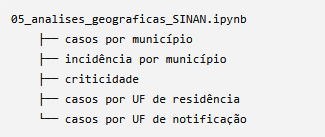

## 1 - Montagem do drive

In [1]:
from google.colab import drive
import os

drive.mount("/content/drive")

Mounted at /content/drive


##2 - Imports

In [2]:
import pandas as pd
import numpy as np

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

## 3. Configuração

In [3]:
# ============================================================
# CONFIGURAÇÃO
# ============================================================

ANO = 2026

PASTA_BASE = Path(
    "/content/drive/MyDrive/Doutorado/arbovirus_rag"
)

PASTA_PROCESSED = (
    PASTA_BASE
    / "data_processed"
    / "SINAN"
    / str(ANO)
)

PASTA_ANALISES = (
    PASTA_BASE
    / "data_analytics"
    / "SINAN"
    / str(ANO)
)

PASTA_ANALISES.mkdir(
    parents=True,
    exist_ok=True
)

ARQUIVO_ENTRADA = (
    PASTA_PROCESSED
    / f"sinan_dengue_{ANO}_enriquecido.parquet"
)

# ============================================================
# DIRETÓRIO DE SAÍDA DOS PRODUTOS GEOGRÁFICOS
# ============================================================

PASTA_SAIDA = (
    PASTA_BASE
    / "data_analytics"
    / "SINAN"
    / str(ANO)
    / "geograficos"
)

PASTA_SAIDA.mkdir(
    parents=True,
    exist_ok=True
)

print(
    f"Pasta de saída:\n{PASTA_SAIDA}"
)

print(f"Ano: {ANO}")
print(f"Entrada: {ARQUIVO_ENTRADA}")
print(f"Saída: {PASTA_ANALISES}")

Pasta de saída:
/content/drive/MyDrive/Doutorado/arbovirus_rag/data_analytics/SINAN/2026/geograficos
Ano: 2026
Entrada: /content/drive/MyDrive/Doutorado/arbovirus_rag/data_processed/SINAN/2026/sinan_dengue_2026_enriquecido.parquet
Saída: /content/drive/MyDrive/Doutorado/arbovirus_rag/data_analytics/SINAN/2026


## 4. Carregar o dataframe enriquecido

In [4]:
# ============================================================
# CARREGAMENTO
# ============================================================

df = pd.read_parquet(
    ARQUIVO_ENTRADA
)

print(
    f"Registros carregados: {len(df):,}"
)

print(
    f"Quantidade de variáveis: {df.shape[1]}"
)

display(
    df.head()
)

Registros carregados: 444,266
Quantidade de variáveis: 171


,TP_NOT,ID_AGRAVO,DT_NOTIFIC,SEM_NOT,NU_ANO,SG_UF_NOT,ID_MUNICIP,ID_REGIONA,ID_UNIDADE,DT_SIN_PRI,SEM_PRI,ANO_NASC,NU_IDADE_N,CS_SEXO,CS_GESTANT,CS_RACA,CS_ESCOL_N,SG_UF,ID_MN_RESI,ID_RG_RESI,ID_PAIS,DT_INVEST,ID_OCUPA_N,FEBRE,MIALGIA,CEFALEIA,EXANTEMA,VOMITO,NAUSEA,DOR_COSTAS,CONJUNTVIT,ARTRITE,ARTRALGIA,PETEQUIA_N,LEUCOPENIA,LACO,DOR_RETRO,DIABETES,HEMATOLOG,HEPATOPAT,RENAL,HIPERTENSA,ACIDO_PEPT,AUTO_IMUNE,DT_CHIK_S1,DT_CHIK_S2,DT_PRNT,RES_CHIKS1,RES_CHIKS2,RESUL_PRNT,DT_SORO,RESUL_SORO,DT_NS1,RESUL_NS1,DT_VIRAL,RESUL_VI_N,DT_PCR,RESUL_PCR_,SOROTIPO,HISTOPA_N,IMUNOH_N,HOSPITALIZ,DT_INTERNA,UF,MUNICIPIO,TPAUTOCTO,COUFINF,COPAISINF,COMUNINF,CLASSI_FIN,CRITERIO,DOENCA_TRA,CLINC_CHIK,EVOLUCAO,DT_OBITO,DT_ENCERRA,ALRM_HIPOT,ALRM_PLAQ,ALRM_VOM,ALRM_SANG,ALRM_HEMAT,ALRM_ABDOM,ALRM_LETAR,ALRM_HEPAT,ALRM_LIQ,DT_ALRM,GRAV_PULSO,GRAV_CONV,GRAV_ENCH,GRAV_INSUF,GRAV_TAQUI,GRAV_EXTRE,GRAV_HIPOT,GRAV_HEMAT,GRAV_MELEN,GRAV_METRO,GRAV_SANG,GRAV_AST,GRAV_MIOC,GRAV_CONSC,GRAV_ORGAO,DT_GRAV,MANI_HEMOR,EPISTAXE,GENGIVO,METRO,PETEQUIAS,HEMATURA,SANGRAM,LACO_N,PLASMATICO,EVIDENCIA,PLAQ_MENOR,CON_FHD,COMPLICA,TP_SISTEMA,NDUPLIC_N,DT_DIGITA,CS_FLXRET,FLXRECEBI,MIGRADO_W,SEMANA_EPIDEMIOLOGICA,ANO_SEM_NOT,UF_NAME,SOROTIPO_ANALITICO,HOSPITALIZ_ANALITICO,EVOLUCAO_ANALITICO,SOROTIPO_DECODED,HOSPITALIZ_DECODED,EVOLUCAO_DECODED,FEBRE_DECODED,MIALGIA_DECODED,CEFALEIA_DECODED,EXANTEMA_DECODED,VOMITO_DECODED,NAUSEA_DECODED,DOR_COSTAS_DECODED,CONJUNTVIT_DECODED,ARTRITE_DECODED,ARTRALGIA_DECODED,PETEQUIA_N_DECODED,LEUCOPENIA_DECODED,LACO_DECODED,DOR_RETRO_DECODED,DIABETES_DECODED,HEMATOLOG_DECODED,HEPATOPAT_DECODED,RENAL_DECODED,HIPERTENSA_DECODED,ACIDO_PEPT_DECODED,AUTO_IMUNE_DECODED,TPAUTOCTO_DECODED,COUFINF_NORMALIZADO,COMUNINF_NORMALIZADO,CODIGO_MUNICIPIO_6,CODIGO_MUNICIPIO_7,MUNICIPIO_NAME,UF_RESIDENCIA,CODIGO_UF_IBGE,REGIAO,POPULACAO_2022,LATITUDE,LONGITUDE,IS_CAPITAL,PIB_PER_CAPITA_2021,COD_MUNICIPIO_PROVAVEL_INFECCAO,MUNICIPIO_PROVAVEL_INFECCAO,UF_PROVAVEL_INFECCAO,COD_UF_PROVAVEL_INFECCAO,REGIAO_PROVAVEL_INFECCAO,UF_PROVAVEL_INFECCAO_CONSISTENTE
0,2,A90,2026-05-19,202620,2026,32,320400,32001,2448653,2026-05-14,202619,1978,4048,F,5,1,8,32,320400,32001,1,2026-05-18,251605,1,1,2,1,2,1,1,2,2,1,1,1,2,1,2,2,2,2,2,2,2,None,None,None,0,0,0,None,4,2026-05-18,1,None,4,None,4,0,0,0,2,None,0,0,1,0,0,0,10,1,0,1,1,None,2026-05-25,0,0,0,0,0,0,0,0,0,None,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2025-11-08,0,0,0,20,2026,Espírito Santo,<NA>,2,1,None,Não,Cura,Sim,Sim,Não,Sim,Não,Sim,Sim,Não,Não,Sim,Sim,Sim,Não,Sim,Não,Não,Não,Não,Não,Não,Não,Sim,<NA>,<NA>,320400,3204005,Pancas,ES,32,Sudeste,18893.0,-19.2229,-40.8534,0.0,16755.0,<NA>,None,None,<NA>,None,None
1,2,A90,2026-01-05,202601,2026,32,320500,32002,2499495,2026-01-04,202601,1984,4041,F,5,4,5,32,320500,32002,1,2026-01-05,0,1,1,1,2,2,2,1,2,2,2,2,2,2,2,2,2,2,2,1,2,2,None,None,None,0,0,0,None,4,2026-01-05,2,None,4,None,4,0,0,0,2,None,0,0,1,0,0,0,10,2,0,1,1,None,2026-01-20,0,0,0,0,0,0,0,0,0,None,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2026-01-05,0,0,0,1,2026,Espírito Santo,<NA>,2,1,None,Não,Cura,Sim,Sim,Sim,Não,Não,Não,Sim,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não,Sim,Não,Não,Sim,<NA>,<NA>,320500,3205002,Serra,ES,32,Sudeste,520653.0,-20.1210,-40.3074,0.0,8471034.0,<NA>,None,None,<NA>,None,None
2,2,A90,2026-01-05,202601,2026,32,320500,32002,2522772,2026-01-05,202601,1991,4034,F,5,2,6,32,320500,32002,1,2026-01-05,322215,1,2,1,2,1,2,2,2,2,2,1,2,2,2,2,2,2,2,2,2,2,None,None,None,0,0,0,None,0,1920-01-05,2,None,4,None,0,0,0,0,2,None,0,0,1,0,0,0,10,2,0,1,1,None,2026-01-20,0,0,0,0,0,0,0,0,0,None,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2026-01-05,0,0,0,1,2026,Espírito Santo,<NA>,2,1,None,Não,Cura,Sim,Não,Sim,Não,Sim,Não,Não,Não,Não,Não,Sim,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não,Sim,<NA>,<NA>,320500,3205002,Serra,ES,32,Sudeste,520653.0,-20.1210,-40.3074,0.0,8471034.0,<NA>,None,None,<NA>,None,None
3,2,A90,2026-01-05,202601,2026,32,320500,32002,7838131,2026-

##5. verificação rápida das variáveis essenciais:

In [5]:
# ============================================================
# VARIÁVEIS NECESSÁRIAS ÀS ANÁLISES GEOGRÁFICAS
# ============================================================

VARIAVEIS_GEOGRAFICAS = [
    # Identificação temporal mínima
    "NU_ANO",

    # Local de notificação
    "SG_UF_NOT",
    "UF_NAME",

    # Local de residência
    "SG_UF",
    "ID_MN_RESI",
    "CODIGO_MUNICIPIO_6",
    "CODIGO_MUNICIPIO_7",
    "MUNICIPIO_NAME",
    "UF_RESIDENCIA",
    "CODIGO_UF_IBGE",
    "REGIAO",

    # População de referência
    "POPULACAO_2022"
]

verificacao_geografica = pd.DataFrame({
    "VARIAVEL": VARIAVEIS_GEOGRAFICAS,
    "EXISTE": [
        coluna in df.columns
        for coluna in VARIAVEIS_GEOGRAFICAS
    ]
})

display(verificacao_geografica)

,VARIAVEL,EXISTE
0,NU_ANO,True
1,SG_UF_NOT,True
2,UF_NAME,True
3,SG_UF,True
4,ID_MN_RESI,True
5,CODIGO_MUNICIPIO_6,True
6,CODIGO_MUNICIPIO_7,True
7,MUNICIPIO_NAME,True
8,UF_RESIDENCIA,True
9,CODIGO_UF_IBGE,True


In [6]:
# ============================================================
# VALIDAR VARIÁVEIS GEOGRÁFICAS
# ============================================================

variaveis_ausentes = (
    verificacao_geografica.loc[
        ~verificacao_geografica["EXISTE"],
        "VARIAVEL"
    ]
    .tolist()
)

if variaveis_ausentes:
    raise ValueError(
        "Variáveis necessárias não encontradas: "
        + ", ".join(variaveis_ausentes)
    )

print(
    "OK — todas as variáveis necessárias "
    "às análises geográficas estão disponíveis."
)

OK — todas as variáveis necessárias às análises geográficas estão disponíveis.


# 6. Casos por município de residência

Agora sim entra aquele bloco que antes estava misturado ao notebook 04.

In [7]:
# ============================================================
# CASOS POR MUNICÍPIO DE RESIDÊNCIA
# ============================================================

casos_municipio = (
    df.groupby(
        [
            "CODIGO_MUNICIPIO_6",
            "CODIGO_MUNICIPIO_7",
            "MUNICIPIO_NAME",
            "UF_RESIDENCIA",
            "REGIAO",
            "POPULACAO_2022"
        ],
        dropna=False
    )
    .size()
    .reset_index(
        name="CASOS"
    )
)

print(
    f"Registros municipais agregados: "
    f"{len(casos_municipio):,}"
)

display(
    casos_municipio.head()
)

Registros municipais agregados: 4,715


,CODIGO_MUNICIPIO_6,CODIGO_MUNICIPIO_7,MUNICIPIO_NAME,UF_RESIDENCIA,REGIAO,POPULACAO_2022,CASOS
0,110000,<NA>,NaN,NaN,NaN,NaN,1
1,110001,1100015,Alta Floresta D'Oeste,RO,Norte,21494.0,102
2,110002,1100023,Ariquemes,RO,Norte,96833.0,103
3,110003,1100031,Cabixi,RO,Norte,5351.0,11
4,110004,1100049,Cacoal,RO,Norte,86887.0,25


Repare que aqui não precisamos fazer novamente o merge com o IBGE.

Esse é justamente o benefício do notebook 04: as informações já estão no df.

In [8]:
# ============================================================
# TOP 10 MUNICÍPIOS COM MAIOR NÚMERO DE CASOS
# ============================================================

top10_municipios_casos = (
    casos_municipio[
        casos_municipio["MUNICIPIO_NAME"].notna()
    ]
    .nlargest(
        10,
        "CASOS"
    )
    .copy()
)

display(
    top10_municipios_casos[
        [
            "MUNICIPIO_NAME",
            "UF_RESIDENCIA",
            "CASOS"
        ]
    ]
)

,MUNICIPIO_NAME,UF_RESIDENCIA,CASOS
4563,Goiânia,GO,31778
4487,Aparecida de Goiânia,GO,21333
3467,São Paulo,SP,9995
821,Teresina,PI,8076
2749,Uberlândia,MG,7605
4665,Rio Verde,GO,7017
4595,Jataí,GO,6938
2844,Serra,ES,5771
3461,São José do Rio Preto,SP,5039
290,Araguaína,TO,4745


In [9]:
top10_municipios_casos["MUNICIPIO_UF"] = (
    top10_municipios_casos["MUNICIPIO_NAME"]
    + " - "
    + top10_municipios_casos["UF_RESIDENCIA"]
)

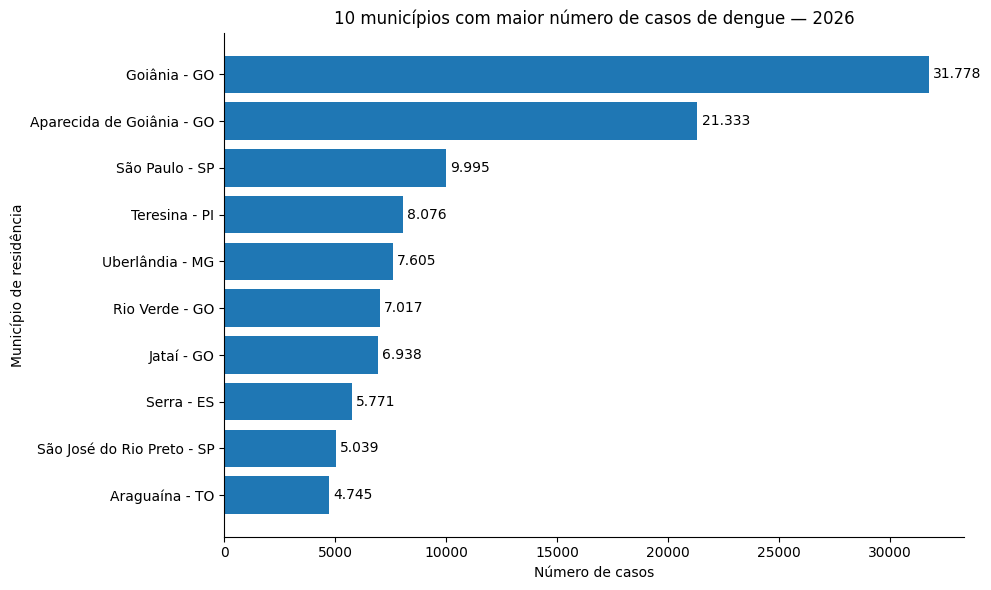

In [10]:
# ============================================================
# GRÁFICO — TOP 10 MUNICÍPIOS COM MAIOR NÚMERO DE CASOS
# ============================================================

import matplotlib.pyplot as plt

dados_grafico = (
    top10_municipios_casos
    .sort_values(
        "CASOS",
        ascending=True
    )
)

fig, ax = plt.subplots(
    figsize=(10, 6)
)

barras = ax.barh(
    dados_grafico["MUNICIPIO_UF"],
    dados_grafico["CASOS"]
)

ax.set_title(
    f"10 municípios com maior número de casos de dengue — {ANO}"
)

ax.set_xlabel(
    "Número de casos"
)

ax.set_ylabel(
    "Município de residência"
)

# Rótulos com os valores
ax.bar_label(
    barras,
    labels=[
        f"{valor:,.0f}".replace(",", ".")
        for valor in dados_grafico["CASOS"]
    ],
    padding=3
)

# Retirar bordas superiores e laterais
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.show()

## 8. Verificar municípios sem população

In [11]:
# ============================================================
# MUNICÍPIOS SEM POPULAÇÃO DE REFERÊNCIA
# ============================================================

municipios_sem_populacao = (
    casos_municipio.loc[
        casos_municipio[
            "MUNICIPIO_NAME"
        ].notna()
        &
        casos_municipio[
            "POPULACAO_2022"
        ].isna()
    ]
    .copy()
)

print(
    f"Municípios identificados sem população de 2022: "
    f"{len(municipios_sem_populacao)}"
)

display(
    municipios_sem_populacao
)

Municípios identificados sem população de 2022: 1


,CODIGO_MUNICIPIO_6,CODIGO_MUNICIPIO_7,MUNICIPIO_NAME,UF_RESIDENCIA,REGIAO,POPULACAO_2022,CASOS
4355,510183,5101837,Boa Esperança do Norte,MT,Centro-Oeste,NaN,23


Aqui esperamos que Boa Esperança do Norte apareça como caso especial.

## 9. Selecionar municípios elegíveis para incidência

Esse trecho cria um novo DataFrame chamado df_incidencia contendo somente os municípios para os quais é possível calcular a incidência de dengue por 100 mil habitantes.

O que significa “elegível”?

Para calcular:



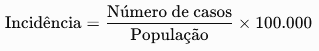

In [12]:
# ============================================================
# MUNICÍPIOS ELEGÍVEIS PARA O CÁLCULO DA INCIDÊNCIA
# ============================================================

df_incidencia = (
    casos_municipio.loc[
        #Mantenha apenas registros em que foi possível identificar o nome do município.
#notna() retorna True quando o valor não está ausente.
        casos_municipio[
            "MUNICIPIO_NAME"
        ].notna()
        &
        #O município precisa possuir população de referência disponível.
        casos_municipio[
            "POPULACAO_2022"
        ].notna()
        &
        (
            casos_municipio[
                "POPULACAO_2022"
            ] > 0
        )
    ]
    .copy()
)

print(
    f"Municípios elegíveis: "
    f"{len(df_incidencia):,}"
)

Municípios elegíveis: 4,711


## 10. Calcular incidência

### Incidência por 100 mil habitantes

A incidência é calculada pela razão entre o número de casos registrados e a população do município, multiplicada por 100.000. Em municípios com populações pequenas, a incidência pode apresentar valores numericamente elevados, inclusive superiores à própria população municipal quando expressa na escala de 100 mil habitantes. Isso **não representa, necessariamente, uma inconsistência,** mas decorre da **padronização do indicador** e deve ser considerado na interpretação dos resultados.

Por exemplo, uma incidência de **9.000 casos por 100 mil habitantes** corresponde a:

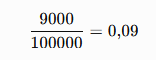

ou seja, aproximadamente **9 casos para cada 100 habitantes** no período analisado.


In [13]:
# ============================================================
# INCIDÊNCIA POR 100 MIL HABITANTES
# ============================================================

df_incidencia[
    "INCIDENCIA_100MIL"
] = (
    (
        df_incidencia[
            "CASOS"
        ]
        /
        df_incidencia[
            "POPULACAO_2022"
        ]
    )
    * 100000
).round(2)

Veja os maiores valores:

In [14]:
display(
    df_incidencia[
        [
            "CODIGO_MUNICIPIO_7",
            "MUNICIPIO_NAME",
            "UF_RESIDENCIA",
            "CASOS",
            "POPULACAO_2022",
            "INCIDENCIA_100MIL"
        ]
    ]
    .sort_values(
        "INCIDENCIA_100MIL",
        ascending=False
    )
    .head(30)
)

,CODIGO_MUNICIPIO_7,MUNICIPIO_NAME,UF_RESIDENCIA,CASOS,POPULACAO_2022,INCIDENCIA_100MIL
4701,5221502,Turvânia,GO,407,4480.0,9084.82
2425,3138906,Machacalis,MG,548,6487.0,8447.66
2415,3138302,Leandro Ferreira,MG,259,3199.0,8096.28
4538,5205901,Corumbaíba,GO,673,9164.0,7343.95
1843,2918704,Lafaiete Coutinho,BA,293,4075.0,7190.18
445,2101806,Benedito Leite,MA,393,5469.0,7185.96
3758,4118303,Paranapoema,PR,162,2398.0,6755.63
4595,5211909,Jataí,GO,6938,105729.0,6562.06
2572,3152808,Prata,MG,1725,28342.0,6086.37
630,2200806,Antônio Almeida,PI,190,3152.0,6027.92


## 11. Auditoria da incidência


In [15]:
# ============================================================
# AUDITORIA DOS CASOS UTILIZADOS NO CÁLCULO
# ============================================================

TOTAL_CASOS = (
    casos_municipio[
        "CASOS"
    ]
    .sum()
)

CASOS_COM_INCIDENCIA = (
    df_incidencia[
        "CASOS"
    ]
    .sum()
)

CASOS_FORA_CALCULO = (
    TOTAL_CASOS
    -
    CASOS_COM_INCIDENCIA
)

PERCENTUAL_FORA = (
    CASOS_FORA_CALCULO
    /
    TOTAL_CASOS
    * 100
)

print(
    f"Casos agregados: "
    f"{TOTAL_CASOS:,}"
)

print(
    f"Casos utilizados no cálculo: "
    f"{CASOS_COM_INCIDENCIA:,}"
)

print(
    f"Casos fora do cálculo: "
    f"{CASOS_FORA_CALCULO:,}"
)

print(
    f"Percentual fora do cálculo: "
    f"{PERCENTUAL_FORA:.4f}%"
)

Casos agregados: 444,266
Casos utilizados no cálculo: 444,233
Casos fora do cálculo: 33
Percentual fora do cálculo: 0.0074%


## 12. Classificação de criticidade


In [16]:
# ============================================================
# CLASSIFICAÇÃO DA CRITICIDADE
# ============================================================

def classificar_criticidade(incidencia):

    if pd.isna(incidencia):
        return "Sem informação"

    elif incidencia < 100:
        return "Baixa"

    elif incidencia < 300:
        return "Média"

    else:
        return "Alta"

Aplicar:

In [17]:
df_incidencia[
    "GRAU_CRITICIDADE"
] = (
    df_incidencia[
        "INCIDENCIA_100MIL"
    ]
    .apply(
        classificar_criticidade
    )
)

Veja:

In [18]:
display(
    df_incidencia[
        "GRAU_CRITICIDADE"
    ]
    .value_counts()
    .reset_index(
        name="TOTAL_MUNICIPIOS"
    )
)

,GRAU_CRITICIDADE,TOTAL_MUNICIPIOS
0,Baixa,2634
1,Média,1070
2,Alta,1007


## 13. Criticidade por UF

In [19]:
# ============================================================
# CRITICIDADE POR UF
# ============================================================

criticidade_por_uf = (
    df_incidencia.groupby(
        [
            "UF_RESIDENCIA",
            "GRAU_CRITICIDADE"
        ]
    )
    .size()
    .reset_index(
        name="TOTAL_MUNICIPIOS"
    )
)

display(
    criticidade_por_uf.sort_values(
        [
            "UF_RESIDENCIA",
            "GRAU_CRITICIDADE"
        ]
    )
)

,UF_RESIDENCIA,GRAU_CRITICIDADE,TOTAL_MUNICIPIOS
0,AC,Alta,6
1,AC,Baixa,6
2,AC,Média,10
3,AL,Alta,10
4,AL,Baixa,54
5,AL,Média,24
6,AM,Alta,3
7,AM,Baixa,34
8,AM,Média,3
9,AP,Alta,2


## 14. Casos por UF de residência

Aqui eu faria duas análises diferentes.

Uma por UF de residência:

In [20]:
# ============================================================
# CASOS POR UF DE RESIDÊNCIA
# ============================================================

casos_por_uf_residencia = (
    df.groupby(
        [
            "SG_UF",
            "UF_RESIDENCIA"
        ],
        dropna=False
    )
    .size()
    .reset_index(
        name="TOTAL_CASOS"
    )
    .sort_values(
        "TOTAL_CASOS",
        ascending=False
    )
)

display(
    casos_por_uf_residencia
)

,SG_UF,UF_RESIDENCIA,TOTAL_CASOS
33,52,GO,108912
26,35,SP,65032
22,31,MG,61668
17,26,PE,22008
21,29,BA,21749
24,32,ES,19045
13,23,CE,17353
10,22,PI,17346
8,17,TO,15296
9,21,MA,12386


##15. E outra por UF de notificação:

In [21]:
# ============================================================
# CASOS POR UF DE NOTIFICAÇÃO
# ============================================================

casos_por_uf_notificacao = (
    df.groupby(
        [
            "SG_UF_NOT",
            "UF_NAME"
        ],
        dropna=False
    )
    .size()
    .reset_index(
        name="TOTAL_CASOS"
    )
    .sort_values(
        "TOTAL_CASOS",
        ascending=False
    )
)

display(
    casos_por_uf_notificacao
)
#print("Soma de casos das semanas{df[]} a {}")

,SG_UF_NOT,UF_NAME,TOTAL_CASOS
25,52,Goiás,108884
19,35,São Paulo,65195
16,31,Minas Gerais,61248
12,26,Pernambuco,22036
15,29,Bahia,21609
17,32,Espírito Santo,19414
8,22,Piauí,17383
9,23,Ceará,17337
6,17,Tocantins,15430
7,21,Maranhão,12282


Essa distinção é importante. Não misturar as duas medidas.

## 16. Produtos geográficos finais

In [22]:
# ============================================================
# PRODUTOS GEOGRÁFICOS FINAIS
# ============================================================

PRODUTOS_GEOGRAFICOS = {

    # Casos por município de residência
    "casos_municipio": casos_municipio,

    # Incidência por município
    "incidencia_municipio": df_incidencia,

    # Classificação da incidência agregada por UF
    "criticidade_uf": criticidade_por_uf,

    # Casos segundo UF de residência
    "casos_uf_residencia": casos_por_uf_residencia,

    # Casos segundo UF de notificação
    "casos_uf_notificacao": casos_por_uf_notificacao
}

print(
    f"Produtos geográficos definidos: "
    f"{len(PRODUTOS_GEOGRAFICOS)}"
)

Produtos geográficos definidos: 5


## 17. Inventário dos produtos

Agora criamos uma tabela que documenta o que o notebook produziu.

Isso é especialmente interessante para sua arquitetura porque permite saber quais artefatos analíticos foram efetivamente gerados antes da etapa de documentos semânticos.

In [23]:
# ============================================================
# INVENTÁRIO DOS PRODUTOS GEOGRÁFICOS
# ============================================================

inventario_produtos_geograficos = []

for nome, produto in PRODUTOS_GEOGRAFICOS.items():

    inventario_produtos_geograficos.append({
        "PRODUTO": nome,
        "LINHAS": len(produto),
        "COLUNAS": len(produto.columns),
        "TOTAL_CELULAS": produto.shape[0] * produto.shape[1]
    })

inventario_produtos_geograficos = pd.DataFrame(
    inventario_produtos_geograficos
)

display(
    inventario_produtos_geograficos
)

,PRODUTO,LINHAS,COLUNAS,TOTAL_CELULAS
0,casos_municipio,4715,7,33005
1,incidencia_municipio,4711,9,42399
2,criticidade_uf,79,3,237
3,casos_uf_residencia,36,3,108
4,casos_uf_notificacao,27,3,81


In [24]:
DESCRICOES_PRODUTOS_GEOGRAFICOS = {

    "casos_municipio":
        "Número de casos de dengue por município de residência.",

    "incidencia_municipio":
        "Número de casos e incidência de dengue por 100 mil "
        "habitantes segundo município de residência.",

    "criticidade_uf":
        "Distribuição dos municípios segundo a classificação "
        "da incidência, agregada por UF.",

    "casos_uf_residencia":
        "Número de casos de dengue segundo UF de residência.",

    "casos_uf_notificacao":
        "Número de casos de dengue segundo UF de notificação."
}

In [25]:
inventario_produtos_geograficos["DESCRICAO"] = (
    inventario_produtos_geograficos["PRODUTO"]
    .map(DESCRICOES_PRODUTOS_GEOGRAFICOS)
)

inventario_produtos_geograficos = (
    inventario_produtos_geograficos[
        [
            "PRODUTO",
            "DESCRICAO",
            "LINHAS",
            "COLUNAS"
        ]
    ]
)

display(inventario_produtos_geograficos)

,PRODUTO,DESCRICAO,LINHAS,COLUNAS
0,casos_municipio,Número de casos de dengue por município de res...,4715,7
1,incidencia_municipio,Número de casos e incidência de dengue por 100...,4711,9
2,criticidade_uf,Distribuição dos municípios segundo a classifi...,79,3
3,casos_uf_residencia,Número de casos de dengue segundo UF de residê...,36,3
4,casos_uf_notificacao,Número de casos de dengue segundo UF de notifi...,27,3


## 18. Salvamento

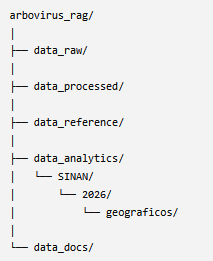

In [26]:
# ============================================================
# SALVAMENTO DOS PRODUTOS GEOGRÁFICOS
# ============================================================

arquivos_salvos = []

for nome, produto in PRODUTOS_GEOGRAFICOS.items():

    caminho = (
        PASTA_SAIDA
        / f"{nome}_{ANO}.parquet"
    )

    produto.to_parquet(
        caminho,
        index=False
    )

    arquivos_salvos.append(caminho)

    print(
        f"Salvo: {caminho.name}"
    )

print(
    f"\nTotal de arquivos salvos: "
    f"{len(arquivos_salvos)}"
)

Salvo: casos_municipio_2026.parquet
Salvo: incidencia_municipio_2026.parquet
Salvo: criticidade_uf_2026.parquet
Salvo: casos_uf_residencia_2026.parquet
Salvo: casos_uf_notificacao_2026.parquet

Total de arquivos salvos: 5


Salvar o inventário

In [27]:
caminho_inventario = (
    PASTA_SAIDA
    / f"inventario_produtos_geograficos_{ANO}.csv"
)

inventario_produtos_geograficos.to_csv(
    caminho_inventario,
    index=False,
    encoding="utf-8-sig"
)

print(
    f"Inventário salvo: "
    f"{caminho_inventario.name}"
)

Inventário salvo: inventario_produtos_geograficos_2026.csv


## 19. Validação dos arquivos

Essa etapa é importante. Não basta executar to_parquet() sem erro; podemos verificar se os arquivos realmente existem e se conseguem ser carregados novamente.

In [28]:
#19.1 Verificar existência
# ============================================================
# VALIDAÇÃO — EXISTÊNCIA DOS ARQUIVOS
# ============================================================

validacao_arquivos = []

for nome in PRODUTOS_GEOGRAFICOS.keys():

    caminho = (
        PASTA_SAIDA
        / f"{nome}_{ANO}.parquet"
    )

    validacao_arquivos.append({
        "PRODUTO": nome,
        "ARQUIVO": caminho.name,
        "EXISTE": caminho.exists()
    })

validacao_arquivos = pd.DataFrame(
    validacao_arquivos
)

display(validacao_arquivos)

,PRODUTO,ARQUIVO,EXISTE
0,casos_municipio,casos_municipio_2026.parquet,True
1,incidencia_municipio,incidencia_municipio_2026.parquet,True
2,criticidade_uf,criticidade_uf_2026.parquet,True
3,casos_uf_residencia,casos_uf_residencia_2026.parquet,True
4,casos_uf_notificacao,casos_uf_notificacao_2026.parquet,True


In [29]:
#19.2 Validar conteúdo
#Carregar cada Parquet novamente:
# ============================================================
# VALIDAÇÃO — INTEGRIDADE DOS ARQUIVOS SALVOS
# ============================================================

validacao_integridade = []

for nome, produto_original in PRODUTOS_GEOGRAFICOS.items():

    caminho = (
        PASTA_SAIDA
        / f"{nome}_{ANO}.parquet"
    )

    try:

        produto_recarregado = pd.read_parquet(
            caminho
        )

        mesmas_linhas = (
            len(produto_original)
            == len(produto_recarregado)
        )

        mesmas_colunas = (
            list(produto_original.columns)
            == list(produto_recarregado.columns)
        )

        valido = (
            mesmas_linhas
            and mesmas_colunas
        )

        validacao_integridade.append({
            "PRODUTO": nome,
            "ARQUIVO_EXISTE": caminho.exists(),
            "LINHAS_ORIGINAL": len(produto_original),
            "LINHAS_ARQUIVO": len(produto_recarregado),
            "MESMAS_LINHAS": mesmas_linhas,
            "MESMAS_COLUNAS": mesmas_colunas,
            "VALIDO": valido
        })

    except Exception as erro:

        validacao_integridade.append({
            "PRODUTO": nome,
            "ARQUIVO_EXISTE": caminho.exists(),
            "LINHAS_ORIGINAL": len(produto_original),
            "LINHAS_ARQUIVO": None,
            "MESMAS_LINHAS": False,
            "MESMAS_COLUNAS": False,
            "VALIDO": False
        })

        print(
            f"Erro ao validar {nome}: {erro}"
        )

validacao_integridade = pd.DataFrame(
    validacao_integridade
)

display(validacao_integridade)

,PRODUTO,ARQUIVO_EXISTE,LINHAS_ORIGINAL,LINHAS_ARQUIVO,MESMAS_LINHAS,MESMAS_COLUNAS,VALIDO
0,casos_municipio,True,4715,4715,True,True,True
1,incidencia_municipio,True,4711,4711,True,True,True
2,criticidade_uf,True,79,79,True,True,True
3,casos_uf_residencia,True,36,36,True,True,True
4,casos_uf_notificacao,True,27,27,True,True,True


19.3 Resultado final do notebook

Para fechar o notebook:

In [30]:
# ============================================================
# RESULTADO FINAL
# ============================================================

if validacao_integridade["VALIDO"].all():

    print("=" * 70)
    print("ANÁLISES GEOGRÁFICAS CONCLUÍDAS COM SUCESSO")
    print("=" * 70)

    print(
        f"\nProdutos gerados: "
        f"{len(PRODUTOS_GEOGRAFICOS)}"
    )

    print(
        f"Arquivos validados: "
        f"{validacao_integridade['VALIDO'].sum()}"
    )

    print(
        f"\nDiretório:\n{PASTA_SAIDA}"
    )

else:

    print("=" * 70)
    print("ATENÇÃO — FORAM ENCONTRADOS PROBLEMAS")
    print("=" * 70)

    display(
        validacao_integridade[
            ~validacao_integridade["VALIDO"]
        ]
    )

ANÁLISES GEOGRÁFICAS CONCLUÍDAS COM SUCESSO

Produtos gerados: 5
Arquivos validados: 5

Diretório:
/content/drive/MyDrive/Doutorado/arbovirus_rag/data_analytics/SINAN/2026/geograficos
